In [3]:
import numpy as np

# 已知向量与矩阵
a = np.array([2, -1, 3])
b = np.array([1, 4, -2])
A = np.array([[1, 0, 2],
              [-1, 3, 1]])
B = np.array([[2, 1],
              [0, -1],
              [3, 2]])

# 1) 向量点积 a·b
dot_ab = np.dot(a, b)
print("1) a·b =", dot_ab)

# 2) 矩阵乘法 A×B（及结果形状）
AB = A @ B
print("\n2) A×B =")
print(AB)
print("A 的形状:", A.shape, "B 的形状:", B.shape, "A×B 的形状:", AB.shape)

# 3) 向量 a 的范数
# 注意：NumPy 中 'fro' 只用于矩阵；对向量使用 2 范数即可（与向量 Frobenius 写法等价）
a_norm = np.linalg.norm(a, ord=2)
print("\n3) ||a||_F（向量等价于2范数）=", a_norm)

1) a·b = -8

2) A×B =
[[ 8  5]
 [ 1 -2]]
A 的形状: (2, 3) B 的形状: (3, 2) A×B 的形状: (2, 2)

3) ||a||_F（向量等价于2范数）= 3.7416573867739413


In [4]:
import numpy as np

# 1) 创建 3x4 标准正态分布随机矩阵 X
X = np.random.randn(3, 4)
print("1) X =")
print(X)
print("X 的形状:", X.shape)

# 2) 创建 4x2 全 1 矩阵 Y
Y = np.ones((4, 2))
print("\n2) Y =")
print(Y)
print("Y 的形状:", Y.shape)

# 3) 计算矩阵乘法 Z = X @ Y
Z = X @ Y
print("\n3) Z = X @ Y =")
print(Z)
print("Z 的形状:", Z.shape)

# 4) 输出 Z 第一行第一列元素，以及 Z 的第 2 行所有元素
print("\n4) Z 第一行第一列元素 Z[0,0] =", Z[0, 0])
print("   Z 第 2 行所有元素 Z[1,:] =", Z[1, :])

# 5) 计算 Z 的 Frobenius 范数
Z_fro = np.linalg.norm(Z, ord='fro')
print("\n5) ||Z||_F =", Z_fro)

1) X =
[[-1.97733206 -2.1220193  -0.35162067 -0.54122288]
 [ 1.50886663 -0.35974651  1.90372665 -0.46609487]
 [ 1.29352861  0.21760684  1.04874011  1.9630876 ]]
X 的形状: (3, 4)

2) Y =
[[1. 1.]
 [1. 1.]
 [1. 1.]
 [1. 1.]]
Y 的形状: (4, 2)

3) Z = X @ Y =
[[-4.99219491 -4.99219491]
 [ 2.58675191  2.58675191]
 [ 4.52296316  4.52296316]]
Z 的形状: (3, 2)

4) Z 第一行第一列元素 Z[0,0] = -4.992194914877183
   Z 第 2 行所有元素 Z[1,:] = [2.58675191 2.58675191]

5) ||Z||_F = 10.204948922188958


In [5]:
# 3.1 贝叶斯公式计算
# 已知：P(D)=0.001, P(+|D)=0.99, P(+|~D)=0.02

P_D = 0.001          # 患病率
P_pos_given_D = 0.99 # 灵敏度
P_pos_given_notD = 0.02  # 假阳性率

# 全概率公式：P(+) = P(+|D)P(D) + P(+|~D)P(~D)
P_pos = P_pos_given_D * P_D + P_pos_given_notD * (1 - P_D)

# 贝叶斯公式：P(D|+) = P(+|D)P(D) / P(+)
P_D_given_pos = (P_pos_given_D * P_D) / P_pos

print("P(+) =", P_pos)
print("P(D|+) =", P_D_given_pos)
print("阳性后真正患病概率 = {:.4f}%".format(P_D_given_pos * 100))

P(+) = 0.020970000000000003
P(D|+) = 0.047210300429184546
阳性后真正患病概率 = 4.7210%


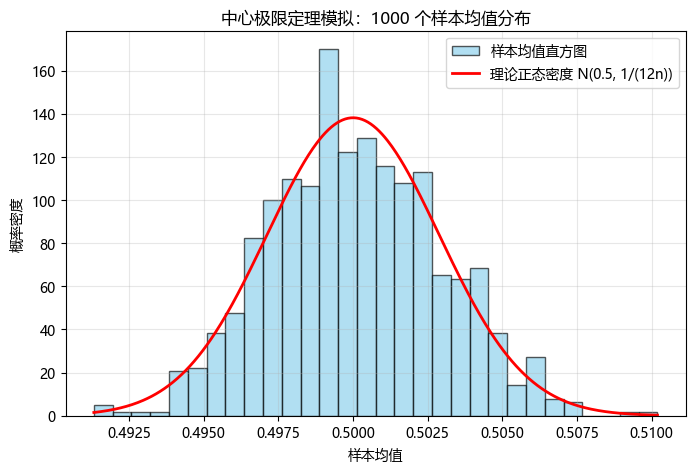

均值的实际方差（样本方差）: 0.0000081425
均值的理论方差: 0.0000083333


In [7]:
import numpy as np
import matplotlib.pyplot as plt

# 解决中文显示乱码和负号显示问题（Windows）
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'Noto Sans CJK SC', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

# 3.2 中心极限定理模拟
n = 10000  # 每次实验的样本量
m = 1000   # 重复次数

# 1) 生成 m 组、每组 n 个 U(0,1) 随机变量，并计算每组均值
samples = np.random.uniform(0, 1, size=(m, n))
means = samples.mean(axis=1)

# U(0,1) 的理论均值与方差
mu = 0.5
var = 1 / 12

# 样本均值的理论分布近似 N(mu, var/n)
sigma_mean = np.sqrt(var / n)

# 2) 绘制均值直方图，并叠加理论正态密度曲线
plt.figure(figsize=(8, 5))
plt.hist(means, bins=30, density=True, alpha=0.65, color='skyblue', edgecolor='k', label='样本均值直方图')

x = np.linspace(means.min(), means.max(), 400)
normal_pdf = (1 / (sigma_mean * np.sqrt(2 * np.pi))) * np.exp(-((x - mu) ** 2) / (2 * sigma_mean ** 2))
plt.plot(x, normal_pdf, 'r-', lw=2, label='理论正态密度 N(0.5, 1/(12n))')

plt.title('中心极限定理模拟：1000 个样本均值分布')
plt.xlabel('样本均值')
plt.ylabel('概率密度')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# 3) 计算这些均值的实际方差（无偏估计）
actual_var = np.var(means, ddof=1)
theoretical_var = var / n

print(f"均值的实际方差（样本方差）: {actual_var:.10f}")
print(f"均值的理论方差: {theoretical_var:.10f}")

In [8]:
# 4.1 理论计算题
# z = (w1*x1 + w2*x2 - y)^2, 其中 x1=2, x2=1, y=3

x1, x2, y = 2, 1, 3

# 1) 偏导表达式
# ∂z/∂w1 = 2*(w1*x1 + w2*x2 - y)*x1
# ∂z/∂w2 = 2*(w1*x1 + w2*x2 - y)*x2
print("1) 偏导表达式：")
print("dz/dw1 = 2*(w1*x1 + w2*x2 - y)*x1")
print("dz/dw2 = 2*(w1*x1 + w2*x2 - y)*x2")

# 2) 代入 w1=0.5, w2=1 计算梯度值
w1, w2 = 0.5, 1
error = w1 * x1 + w2 * x2 - y

dz_dw1 = 2 * error * x1
dz_dw2 = 2 * error * x2

print("\n2) 当 w1=0.5, w2=1 时：")
print("error =", error)
print("dz/dw1 =", dz_dw1)
print("dz/dw2 =", dz_dw2)
print("梯度向量 = (dz/dw1, dz/dw2) = ({}, {})".format(dz_dw1, dz_dw2))

1) 偏导表达式：
dz/dw1 = 2*(w1*x1 + w2*x2 - y)*x1
dz/dw2 = 2*(w1*x1 + w2*x2 - y)*x2

2) 当 w1=0.5, w2=1 时：
error = -1.0
dz/dw1 = -4.0
dz/dw2 = -2.0
梯度向量 = (dz/dw1, dz/dw2) = (-4.0, -2.0)


In [ ]:
# 前向定义：a = x*w1, b = a+w2, L = b^2
x = 2.0
w1 = 1.5
w2 = 0.5

# 1) 前向计算
a = x * w1
b = a + w2
L = b ** 2

print("前向结果：")
print(f"a = {a}")
print(f"b = {b}")
print(f"L = {L}")

# 2) 手动反向传播（链式法则）
# dL/db = 2b
# db/dw1 = x, db/dw2 = 1
# dL/dw1 = dL/db * db/dw1 = 2b*x
# dL/dw2 = dL/db * db/dw2 = 2b

dL_db = 2 * b
dL_dw1_manual = dL_db * x
dL_dw2_manual = dL_db * 1

print("\n手动反向传播梯度：")
print(f"dL/dw1 (manual) = {dL_dw1_manual}")
print(f"dL/dw2 (manual) = {dL_dw2_manual}")

# 3) 用 torch.autograd 验证
try:
    import torch

    x_t = torch.tensor(x)
    w1_t = torch.tensor(w1, requires_grad=True)
    w2_t = torch.tensor(w2, requires_grad=True)

    a_t = x_t * w1_t
    b_t = a_t + w2_t
    L_t = b_t ** 2

    L_t.backward()

    dL_dw1_auto = w1_t.grad.item()
    dL_dw2_auto = w2_t.grad.item()

    print("\nautograd 梯度：")
    print(f"dL/dw1 (auto) = {dL_dw1_auto}")
    print(f"dL/dw2 (auto) = {dL_dw2_auto}")

    print("\n一致性检查：")
    print("w1 梯度一致：", abs(dL_dw1_manual - dL_dw1_auto) < 1e-8)
    print("w2 梯度一致：", abs(dL_dw2_manual - dL_dw2_auto) < 1e-8)

except ImportError:
    print("\n当前环境未安装 PyTorch，无法进行 autograd 验证。")

前向结果：
a = 3.0
b = 3.5
L = 12.25

手动反向传播梯度：
dL/dw1 (manual) = 14.0
dL/dw2 (manual) = 7.0

autograd 梯度：
dL/dw1 (auto) = 14.0
dL/dw2 (auto) = 7.0

一致性检查：
w1 梯度一致： True
w2 梯度一致： True


In [11]:
# 5.1 理论计算题
# 线性回归：y_hat_i = w*x_i + b
# 损失函数：L = (1/n) * Σ_{i=1}^n (y_i - y_hat_i)^2

print("设 e_i = y_i - (w*x_i + b)")
print("L = (1/n) * Σ e_i^2")

# 对 w 求偏导：
# ∂L/∂w = (1/n) * Σ 2*e_i * ∂e_i/∂w
# ∂e_i/∂w = -x_i
# => ∂L/∂w = -(2/n) * Σ x_i * (y_i - (w*x_i + b))

# 对 b 求偏导：
# ∂L/∂b = (1/n) * Σ 2*e_i * ∂e_i/∂b
# ∂e_i/∂b = -1
# => ∂L/∂b = -(2/n) * Σ (y_i - (w*x_i + b))

print("\n偏导结果（求和形式）：")
print("dL/dw = -(2/n) * Σ[ x_i * (y_i - (w*x_i + b)) ]")
print("dL/db = -(2/n) * Σ[ y_i - (w*x_i + b) ]")

设 e_i = y_i - (w*x_i + b)
L = (1/n) * Σ e_i^2

偏导结果（求和形式）：
dL/dw = -(2/n) * Σ[ x_i * (y_i - (w*x_i + b)) ]
dL/db = -(2/n) * Σ[ y_i - (w*x_i + b) ]


In [12]:
# 5.2 编程题：从零实现 softmax 回归（使用 sklearn 手写数字数据）
import numpy as np
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split

# 1) 加载数据
data = load_digits()
X = data.data.astype(np.float64)   # (N, 64)
y = data.target.astype(np.int64)   # (N,)
num_classes = 10

# 简单归一化到 [0,1]
X = X / 16.0

# 划分训练/测试集
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 2) one-hot 编码

def one_hot(labels, k):
    out = np.zeros((labels.shape[0], k), dtype=np.float64)
    out[np.arange(labels.shape[0]), labels] = 1.0
    return out

y_train_oh = one_hot(y_train, num_classes)

# 3) softmax 与交叉熵

def softmax(logits):
    # 数值稳定：减去每行最大值
    shifted = logits - np.max(logits, axis=1, keepdims=True)
    exp_scores = np.exp(shifted)
    return exp_scores / np.sum(exp_scores, axis=1, keepdims=True)

def cross_entropy(probs, y_onehot):
    eps = 1e-12
    return -np.mean(np.sum(y_onehot * np.log(probs + eps), axis=1))

# 参数初始化
n_train, n_features = X_train.shape
W = np.zeros((n_features, num_classes), dtype=np.float64)
b = np.zeros((1, num_classes), dtype=np.float64)

# 4) 小批量 SGD 训练
batch_size = 32
lr = 0.1
epochs = 50

for epoch in range(epochs):
    # 每个 epoch 打乱
    perm = np.random.permutation(n_train)
    X_train_shuffled = X_train[perm]
    y_train_oh_shuffled = y_train_oh[perm]

    for i in range(0, n_train, batch_size):
        xb = X_train_shuffled[i:i + batch_size]
        yb = y_train_oh_shuffled[i:i + batch_size]

        # 前向
        logits = xb @ W + b
        probs = softmax(logits)

        # 反向（对 logits 的梯度）
        m = xb.shape[0]
        dlogits = (probs - yb) / m

        # 参数梯度
        dW = xb.T @ dlogits
        db = np.sum(dlogits, axis=0, keepdims=True)

        # 更新
        W -= lr * dW
        b -= lr * db

    # 可选：每 10 轮输出一次训练损失
    if (epoch + 1) % 10 == 0:
        train_probs = softmax(X_train @ W + b)
        train_loss = cross_entropy(train_probs, y_train_oh)
        print(f"Epoch {epoch + 1:02d}/{epochs}, train loss = {train_loss:.4f}")

# 5) 测试集准确率
test_logits = X_test @ W + b
test_pred = np.argmax(test_logits, axis=1)
test_acc = np.mean(test_pred == y_test)
print(f"\n测试集准确率: {test_acc * 100:.2f}%")

Epoch 10/50, train loss = 0.4380
Epoch 20/50, train loss = 0.2922
Epoch 30/50, train loss = 0.2345
Epoch 40/50, train loss = 0.2020
Epoch 50/50, train loss = 0.1805

测试集准确率: 95.56%


In [13]:
# 6.1 理论计算题：正态分布参数的最大似然估计

print("设样本 x1,...,xn 独立同分布于 N(μ,σ^2)。")

print("\n1) 似然函数：")
print("L(μ,σ^2) = ∏_{i=1}^n [ 1/sqrt(2πσ^2) * exp(-(x_i-μ)^2/(2σ^2)) ]")
print("        = (2πσ^2)^(-n/2) * exp( - (1/(2σ^2)) * Σ_{i=1}^n (x_i-μ)^2 )")

print("\n对应对数似然：")
print("l(μ,σ^2) = -n/2 * ln(2π) - n/2 * ln(σ^2) - (1/(2σ^2)) * Σ_{i=1}^n (x_i-μ)^2")

print("\n2) 对 μ 求导并令其为 0：")
print("∂l/∂μ = (1/σ^2) * Σ_{i=1}^n (x_i-μ) = 0")
print("=> Σ x_i - nμ = 0")
print("=> μ_hat = (1/n) * Σ_{i=1}^n x_i")

print("\n3) 对 σ^2 求导并令其为 0：")
print("∂l/∂σ^2 = -n/(2σ^2) + (1/(2σ^4)) * Σ_{i=1}^n (x_i-μ)^2 = 0")
print("=> σ^2_hat = (1/n) * Σ_{i=1}^n (x_i-μ_hat)^2")

print("\n结论：")
print("μ 的 MLE: μ_hat = 平均值")
print("σ^2 的 MLE: σ^2_hat = 以 n 为分母的样本方差")

设样本 x1,...,xn 独立同分布于 N(μ,σ^2)。

1) 似然函数：
L(μ,σ^2) = ∏_{i=1}^n [ 1/sqrt(2πσ^2) * exp(-(x_i-μ)^2/(2σ^2)) ]
        = (2πσ^2)^(-n/2) * exp( - (1/(2σ^2)) * Σ_{i=1}^n (x_i-μ)^2 )

对应对数似然：
l(μ,σ^2) = -n/2 * ln(2π) - n/2 * ln(σ^2) - (1/(2σ^2)) * Σ_{i=1}^n (x_i-μ)^2

2) 对 μ 求导并令其为 0：
∂l/∂μ = (1/σ^2) * Σ_{i=1}^n (x_i-μ) = 0
=> Σ x_i - nμ = 0
=> μ_hat = (1/n) * Σ_{i=1}^n x_i

3) 对 σ^2 求导并令其为 0：
∂l/∂σ^2 = -n/(2σ^2) + (1/(2σ^4)) * Σ_{i=1}^n (x_i-μ)^2 = 0
=> σ^2_hat = (1/n) * Σ_{i=1}^n (x_i-μ_hat)^2

结论：
μ 的 MLE: μ_hat = 平均值
σ^2 的 MLE: σ^2_hat = 以 n 为分母的样本方差


iter  200/1000, loss = 0.0245
iter  400/1000, loss = 0.0184
iter  600/1000, loss = 0.0161
iter  800/1000, loss = 0.0148
iter 1000/1000, loss = 0.0139


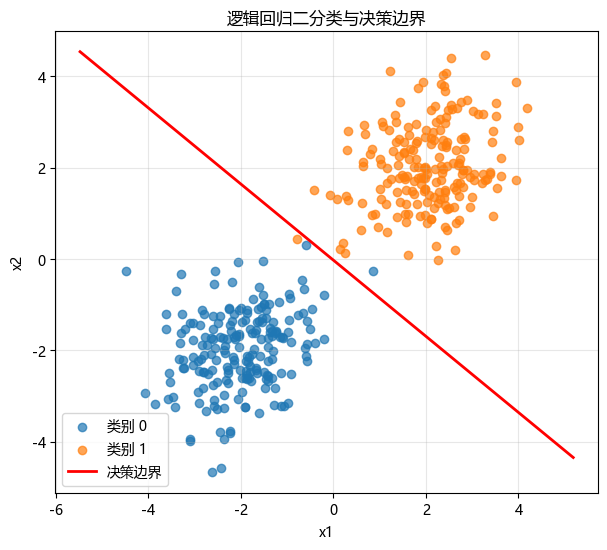


测试集准确率: 100.00%
训练后参数：w = [1.74788397 2.09690877] , b = 0.05669393158148737


In [14]:
# 6.2 编程题：从零实现二分类逻辑回归
import numpy as np
import matplotlib.pyplot as plt

# 中文显示配置
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'Noto Sans CJK SC', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

# 1) 生成线性可分数据（每类 200 个样本，2 维）
np.random.seed(42)

n_per_class = 200
mean0 = np.array([-2.0, -2.0])
mean1 = np.array([2.0, 2.0])
cov = np.array([[0.8, 0.2],
                [0.2, 0.8]])

X0 = np.random.multivariate_normal(mean0, cov, n_per_class)
X1 = np.random.multivariate_normal(mean1, cov, n_per_class)

X_train = np.vstack([X0, X1])                       # (400, 2)
y_train = np.hstack([np.zeros(n_per_class),
                     np.ones(n_per_class)])         # (400,)

# 2) sigmoid 和二元交叉熵

def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))

def binary_cross_entropy(y_true, y_prob):
    eps = 1e-12
    y_prob = np.clip(y_prob, eps, 1 - eps)
    return -np.mean(y_true * np.log(y_prob) + (1 - y_true) * np.log(1 - y_prob))

# 3) 梯度下降训练参数 w,b
w = np.zeros(X_train.shape[1])  # (2,)
b = 0.0

lr = 0.1
num_iters = 1000
n = X_train.shape[0]

for it in range(num_iters):
    logits = X_train @ w + b
    y_prob = sigmoid(logits)

    # 损失对 logits 的梯度: (y_prob - y)
    error = y_prob - y_train
    dw = (X_train.T @ error) / n
    db = np.mean(error)

    w -= lr * dw
    b -= lr * db

    if (it + 1) % 200 == 0:
        loss = binary_cross_entropy(y_train, y_prob)
        print(f"iter {it + 1:4d}/{num_iters}, loss = {loss:.4f}")

# 4) 绘制决策边界
plt.figure(figsize=(7, 6))
plt.scatter(X0[:, 0], X0[:, 1], c='tab:blue', alpha=0.7, label='类别 0')
plt.scatter(X1[:, 0], X1[:, 1], c='tab:orange', alpha=0.7, label='类别 1')

x_min, x_max = X_train[:, 0].min() - 1, X_train[:, 0].max() + 1
xx = np.linspace(x_min, x_max, 200)

# 决策边界：w1*x1 + w2*x2 + b = 0
if abs(w[1]) > 1e-12:
    yy = -(w[0] * xx + b) / w[1]
    plt.plot(xx, yy, 'r-', lw=2, label='决策边界')

plt.title('逻辑回归二分类与决策边界')
plt.xlabel('x1')
plt.ylabel('x2')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# 生成测试集（新生成 100 个样本）并计算准确率
n_test_per_class = 50
X0_test = np.random.multivariate_normal(mean0, cov, n_test_per_class)
X1_test = np.random.multivariate_normal(mean1, cov, n_test_per_class)
X_test = np.vstack([X0_test, X1_test])
y_test = np.hstack([np.zeros(n_test_per_class), np.ones(n_test_per_class)])

y_test_prob = sigmoid(X_test @ w + b)
y_test_pred = (y_test_prob >= 0.5).astype(float)
acc = np.mean(y_test_pred == y_test)

print(f"\n测试集准确率: {acc * 100:.2f}%")
print("训练后参数：w =", w, ", b =", b)